## EDA for BLS Occupation Data
#### Actions
- Feature Engineering for Tier 1 (highest) and Tier 2 (med) occupation codes
- Check occupation labels are consistent YoY 
- Start some Initial Line Charts for Technology Category 

#### Metrics
- % of employment market made up of technology jobs
- raw count of technology jobs over time 
- shifting % of jobs over time

In [65]:
import pandas as pd
from pathlib import Path

# Import National Employment Stats 
file_path = 'national_bls_stats_cleaned.xlsx'
df = pd.read_excel(file_path)


In [37]:
df.head()

,Year,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,...,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY,ONE_OR_THREE
0,2024.0,99.0,U.S.,1.0,US,0.0,Cross-industry,cross-industry,1235.0,00-0000,...,37.89,60.44,29990,36730,49500,78810,125720,NaN,NaN,NaN
1,2024.0,99.0,U.S.,1.0,US,0.0,Cross-industry,cross-industry,1235.0,11-0000,...,82.5,#,57010,79900,122090,171610,#,NaN,NaN,NaN
2,2024.0,99.0,U.S.,1.0,US,0.0,Cross-industry,cross-industry,1235.0,11-1000,...,81.01,#,47510,68800,104990,168490,#,NaN,NaN,NaN
3,2024.0,99.0,U.S.,1.0,US,0.0,Cross-industry,cross-industry,1235.0,11-1010,...,#,#,73710,126080,206420,#,#,NaN,NaN,NaN
4,2024.0,99.0,U.S.,1.0,US,0.0,Cross-industry,cross-industry,1235.0,11-1011,...,#,#,73710,126080,206420,#,#,NaN,NaN,NaN


In [38]:
df.columns

Index(['Year', 'AREA', 'AREA_TITLE', 'AREA_TYPE', 'PRIM_STATE', 'NAICS',
       'NAICS_TITLE', 'I_GROUP', 'OWN_CODE', 'OCC_CODE', 'OCC_CODE_CLEANED',
       'OCC_TITLE', 'O_GROUP', 'TOT_EMP', 'EMP_PRSE', 'JOBS_1000',
       'LOC_QUOTIENT', 'PCT_TOTAL', 'PCT_RPT', 'H_MEAN', 'A_MEAN', 'MEAN_PRSE',
       'H_PCT10', 'H_PCT25', 'H_MEDIAN', 'H_PCT75', 'H_PCT90', 'A_PCT10',
       'A_PCT25', 'A_MEDIAN', 'A_PCT75', 'A_PCT90', 'ANNUAL', 'HOURLY',
       'ONE_OR_THREE'],
      dtype='object')

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29894 entries, 0 to 29893
Data columns (total 35 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              29893 non-null  float64
 1   AREA              8269 non-null   float64
 2   AREA_TITLE        8269 non-null   object 
 3   AREA_TYPE         8269 non-null   float64
 4   PRIM_STATE        6940 non-null   object 
 5   NAICS             8269 non-null   float64
 6   NAICS_TITLE       8269 non-null   object 
 7   I_GROUP           8269 non-null   object 
 8   OWN_CODE          8269 non-null   float64
 9   OCC_CODE          29893 non-null  object 
 10  OCC_CODE_CLEANED  29893 non-null  object 
 11  OCC_TITLE         29894 non-null  object 
 12  O_GROUP           18390 non-null  object 
 13  TOT_EMP           29880 non-null  object 
 14  EMP_PRSE          29879 non-null  object 
 15  JOBS_1000         0 non-null      float64
 16  LOC_QUOTIENT      0 non-null      float6

#### Discoveries
1. JOBS_1000, LOC_QUOTIENT, PCT_TOTAL, PCT_RPT are all null completely -- drop
2. YEAR needs to be changed to datetime
3. AREA, AREA_TITLE, AREA_TYPE, PRIM_STATE,	NAICS, NAICS_TITLE, I_GROUP, OWN_CODE all have only one value it appears in the excel, validate this then drop
4. Some renaming could help 

In [40]:
# Drop completely null columns
df = df.drop(columns=['JOBS_1000','OCC_CODE', 'LOC_QUOTIENT', 'PCT_TOTAL', 'PCT_RPT'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29894 entries, 0 to 29893
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              29893 non-null  float64
 1   AREA              8269 non-null   float64
 2   AREA_TITLE        8269 non-null   object 
 3   AREA_TYPE         8269 non-null   float64
 4   PRIM_STATE        6940 non-null   object 
 5   NAICS             8269 non-null   float64
 6   NAICS_TITLE       8269 non-null   object 
 7   I_GROUP           8269 non-null   object 
 8   OWN_CODE          8269 non-null   float64
 9   OCC_CODE_CLEANED  29893 non-null  object 
 10  OCC_TITLE         29894 non-null  object 
 11  O_GROUP           18390 non-null  object 
 12  TOT_EMP           29880 non-null  object 
 13  EMP_PRSE          29879 non-null  object 
 14  H_MEAN            29879 non-null  object 
 15  A_MEAN            29879 non-null  object 
 16  MEAN_PRSE         29879 non-null  object

In [41]:
# Check unique values in single-value columns
single_value_cols = ['AREA', 'AREA_TITLE', 'AREA_TYPE', 'PRIM_STATE', 'NAICS', 'NAICS_TITLE', 'I_GROUP', 'OWN_CODE']
for col in single_value_cols:
    n_unique = df[col].nunique()
    print(f"{col}: {n_unique} unique value(s)")
    


AREA: 1 unique value(s)
AREA_TITLE: 1 unique value(s)
AREA_TYPE: 1 unique value(s)
PRIM_STATE: 1 unique value(s)
NAICS: 1 unique value(s)
NAICS_TITLE: 1 unique value(s)
I_GROUP: 1 unique value(s)
OWN_CODE: 1 unique value(s)


 They only show a single value to signal that this data is from the USA.

In [42]:
# Drop columns with only 1 unique value
df = df.drop(columns=single_value_cols)
print(f"\nDropped {len(single_value_cols)} columns. Remaining shape: {df.shape}")


Dropped 8 columns. Remaining shape: (29894, 22)


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29894 entries, 0 to 29893
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              29893 non-null  float64
 1   OCC_CODE_CLEANED  29893 non-null  object 
 2   OCC_TITLE         29894 non-null  object 
 3   O_GROUP           18390 non-null  object 
 4   TOT_EMP           29880 non-null  object 
 5   EMP_PRSE          29879 non-null  object 
 6   H_MEAN            29879 non-null  object 
 7   A_MEAN            29879 non-null  object 
 8   MEAN_PRSE         29879 non-null  object 
 9   H_PCT10           29879 non-null  object 
 10  H_PCT25           29879 non-null  object 
 11  H_MEDIAN          29879 non-null  object 
 12  H_PCT75           29879 non-null  object 
 13  H_PCT90           29879 non-null  object 
 14  A_PCT10           29879 non-null  object 
 15  A_PCT25           29879 non-null  object 
 16  A_MEDIAN          29879 non-null  object

### Data Type Changes

- Annual and Hourly and True/False mostly null 
- YEAR is datetime
- OCC_CODE_CLEANED, OCC_TITLE, O_GROUP are all text 
- The rest are numericals *They need to be cleaned from 'star', '#' ,'~' text fields*

In [44]:
# Convert data types
# Text fields
df['ANNUAL'] = df['ANNUAL'].astype(str)
df['HOURLY'] = df['HOURLY'].astype(str)
df['OCC_CODE_CLEANED'] = df['OCC_CODE_CLEANED'].astype(str)
df['OCC_TITLE'] = df['OCC_TITLE'].astype(str)
df['O_GROUP'] = df['O_GROUP'].astype(str)

# Convert YEAR to datetime
df['Year'] = pd.to_datetime(df['Year'], format='%Y')

# Convert remaining numerical fields, converting strings to NaN
numeric_cols = [col for col in df.columns if col not in ['ANNUAL', 'HOURLY', 'OCC_CODE_CLEANED', 'OCC_TITLE', 'O_GROUP', 'Year']]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data types after conversion:")
print(df.dtypes)

Data types after conversion:
Year                datetime64[ns]
OCC_CODE_CLEANED            object
OCC_TITLE                   object
O_GROUP                     object
TOT_EMP                    float64
EMP_PRSE                   float64
H_MEAN                     float64
A_MEAN                     float64
MEAN_PRSE                  float64
H_PCT10                    float64
H_PCT25                    float64
H_MEDIAN                   float64
H_PCT75                    float64
H_PCT90                    float64
A_PCT10                    float64
A_PCT25                    float64
A_MEDIAN                   float64
A_PCT75                    float64
A_PCT90                    float64
ANNUAL                      object
HOURLY                      object
ONE_OR_THREE               float64
dtype: object


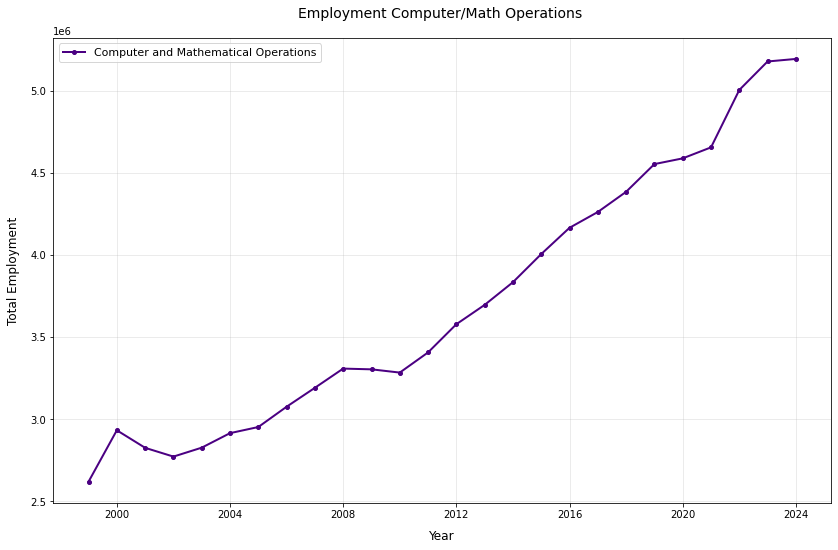

In [54]:
import matplotlib.pyplot as plt

# Filter for both occupation codes
tech_df = df[df['OCC_CODE_CLEANED'] == '15-0000'].copy()


# Sort by Year for proper line chart
filtered_df = filtered_df.sort_values('Year')

# Create line chart with both lines
plt.figure(figsize=(12, 8))
plt.plot(tech_df['Year'], tech_df['TOT_EMP'], marker='o', linewidth=2, markersize=4, label='Computer and Mathematical Operations', color='#4B0082')
plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Total Employment', fontsize=12, labelpad=10)
plt.title('Employment Computer/Math Operations ', fontsize=14, pad=20)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=2.0)
plt.show()

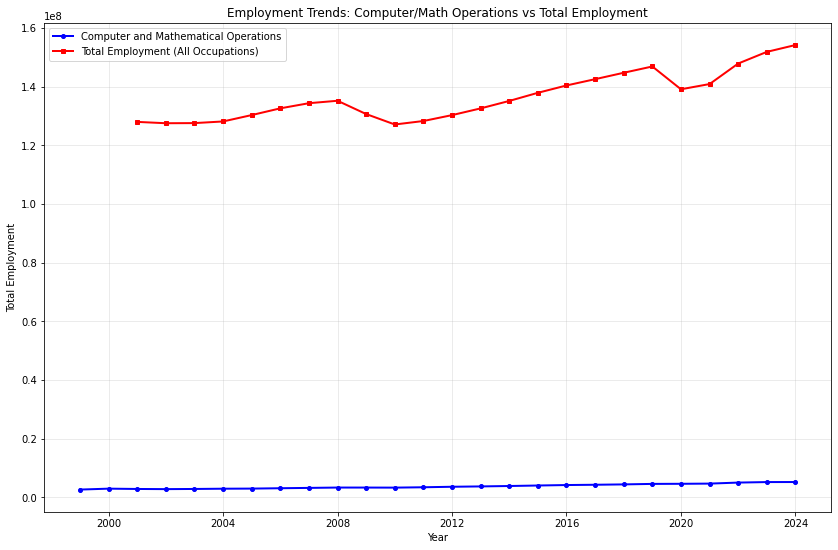

In [55]:
import matplotlib.pyplot as plt

# Filter for both occupation codes
tech_df = df[df['OCC_CODE_CLEANED'] == '15-0000'].copy()
total_df = df[df['OCC_CODE_CLEANED'] == '00-0000'].copy()

# Sort both datasets by Year
tech_df = tech_df.sort_values('Year')
total_df = total_df.sort_values('Year')

# Create line chart with both lines
plt.figure(figsize=(12, 8))
plt.plot(tech_df['Year'], tech_df['TOT_EMP'], marker='o',  linewidth=2, markersize=4, label='Computer and Mathematical Operations', color='blue')
plt.plot(total_df['Year'], total_df['TOT_EMP'], marker='s',  linewidth=2, markersize=4, label='Total Employment (All Occupations)', color='red')
plt.xlabel('Year')
plt.ylabel('Total Employment')
plt.title('Employment Trends: Computer/Math Operations vs Total Employment')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=2.0)
plt.show()

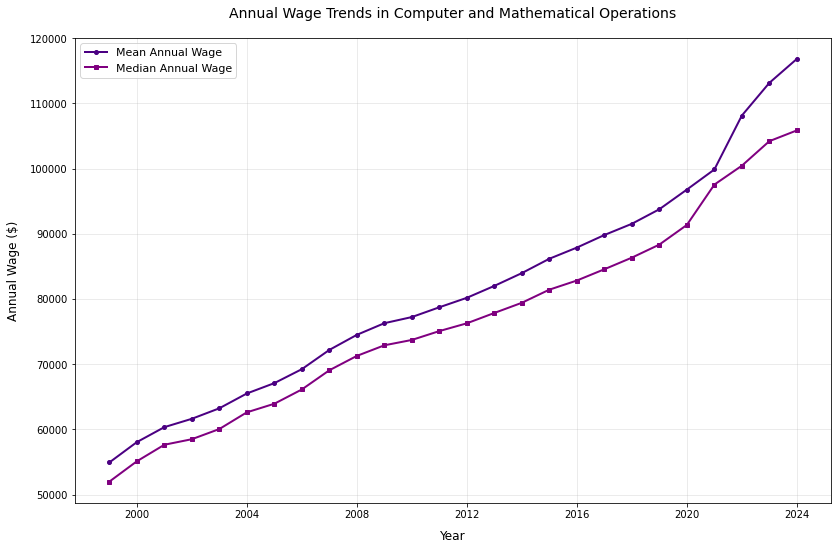

In [58]:
import matplotlib.pyplot as plt

# Filter for Computer and Mathematical Operations
tech_df = df[df['OCC_CODE_CLEANED'] == '15-0000'].copy()

# Sort by Year
tech_df = tech_df.sort_values('Year')

# Create line chart for A_MEAN and A_MEDIAN
plt.figure(figsize=(12, 8))
plt.plot(tech_df['Year'], tech_df['A_MEAN'], marker='o', linewidth=2, markersize=4, label='Mean Annual Wage', color='#4B0082')
plt.plot(tech_df['Year'], tech_df['A_MEDIAN'], marker='s', linewidth=2, markersize=4, label='Median Annual Wage', color='#800080')
plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Annual Wage ($)', fontsize=12, labelpad=10)
plt.title('Annual Wage Trends in Computer and Mathematical Operations', fontsize=14, pad=20)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=2.0)
plt.show()

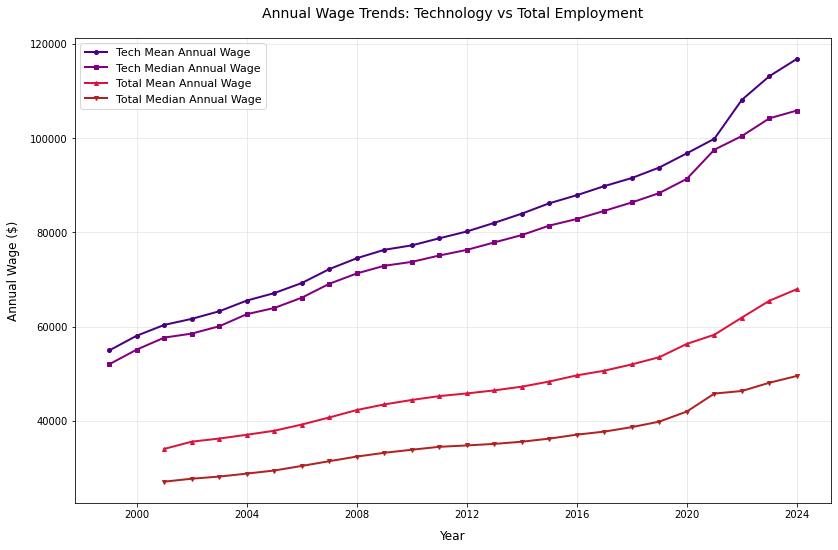

In [57]:
import matplotlib.pyplot as plt

# Filter for both occupation codes
tech_df = df[df['OCC_CODE_CLEANED'] == '15-0000'].copy()
total_df = df[df['OCC_CODE_CLEANED'] == '00-0000'].copy()

# Sort both datasets by Year
tech_df = tech_df.sort_values('Year')
total_df = total_df.sort_values('Year')

# Create line chart for A_MEAN and A_MEDIAN
plt.figure(figsize=(12, 8))
plt.plot(tech_df['Year'], tech_df['A_MEAN'], marker='o', linewidth=2, markersize=4, label='Tech Mean Annual Wage', color='#4B0082')
plt.plot(tech_df['Year'], tech_df['A_MEDIAN'], marker='s', linewidth=2, markersize=4, label='Tech Median Annual Wage', color='#800080')
plt.plot(total_df['Year'], total_df['A_MEAN'], marker='^', linewidth=2, markersize=4, label='Total Mean Annual Wage', color='#DC143C')
plt.plot(total_df['Year'], total_df['A_MEDIAN'], marker='v', linewidth=2, markersize=4, label='Total Median Annual Wage', color='#B22222')
plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Annual Wage ($)', fontsize=12, labelpad=10)
plt.title('Annual Wage Trends: Technology vs Total Employment', fontsize=14, pad=20)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=2.0)
plt.show()

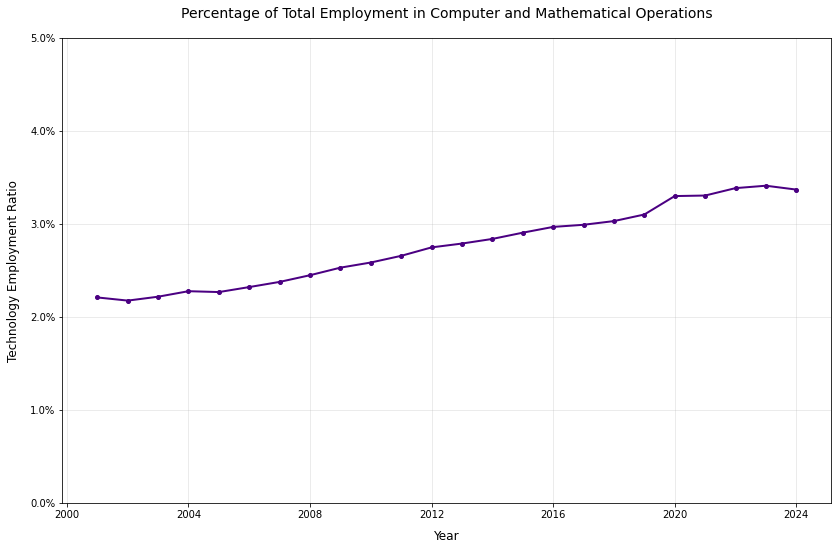

Technology Employment as % of Total Employment:
      Year  tech_ratio
2001-01-01    0.022080
2002-01-01    0.021742
2003-01-01    0.022161
2004-01-01    0.022753
2005-01-01    0.022660
2006-01-01    0.023198
2007-01-01    0.023753
2008-01-01    0.024472
2009-01-01    0.025287
2010-01-01    0.025838
2011-01-01    0.026557
2012-01-01    0.027464
2013-01-01    0.027877
2014-01-01    0.028374
2015-01-01    0.029045
2016-01-01    0.029666
2017-01-01    0.029895
2018-01-01    0.030292
2019-01-01    0.030998
2020-01-01    0.032981
2021-01-01    0.033039
2022-01-01    0.033836
2023-01-01    0.034095
2024-01-01    0.033679


In [64]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Filter for both occupation codes
tech_df = df[df['OCC_CODE_CLEANED'] == '15-0000'][['Year', 'TOT_EMP']].copy()
total_df = df[df['OCC_CODE_CLEANED'] == '00-0000'][['Year', 'TOT_EMP']].copy()

# Merge on Year to get both values for each year
merged_df = pd.merge(tech_df, total_df, on='Year', suffixes=('_tech', '_total'))

# Calculate the ratio (tech employment / total employment)
merged_df['tech_ratio'] = merged_df['TOT_EMP_tech'] / merged_df['TOT_EMP_total']

# Sort by Year
merged_df = merged_df.sort_values('Year')

# Create line chart
plt.figure(figsize=(12, 8))
plt.plot(merged_df['Year'], merged_df['tech_ratio'], marker='o', linewidth=2, markersize=4, color='#4B0082')
plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Technology Employment Ratio', fontsize=12, labelpad=10)
plt.title('Percentage of Total Employment in Computer and Mathematical Operations', fontsize=14, pad=20)
plt.ylim(0, .05)
# Format y-axis as percentage
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.1f}%'))
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=2.0)
plt.show()

# Display the ratio values
print("Technology Employment as % of Total Employment:")
print(merged_df[['Year', 'tech_ratio']].to_string(index=False))